# Completar niveles de juego (Redes de Bayes)

Actividad basada en probabilidades por frecuencias y Naive Bayes.

Variables:
- Éxito de la Misión (EM): Sí/No
- Nivel de Experiencia (NE): Bajo/Medio/Alto
- Equipamiento (EQ): Básico/Intermedio/Avanzado
- Habilidades (H): Bajas/Medias/Altas
- Salud (S): Baja/Media/Alta
- Estado Mental (EMe): Positivo/Neutral/Negativo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# Simular datos
np.random.seed(42)
n_samples = 100000

data = pd.DataFrame({
    'Experiencia': np.random.choice(['Bajo', 'Medio', 'Alto'], size=n_samples, p=[0.30, 0.45, 0.25]),
    'Equipamiento': np.random.choice(['Básico', 'Intermedio', 'Avanzado'], size=n_samples, p=[0.35, 0.45, 0.20]),
    'Habilidades': np.random.choice(['Bajas', 'Medias', 'Altas'], size=n_samples, p=[0.30, 0.45, 0.25]),
    'Salud': np.random.choice(['Baja', 'Media', 'Alta'], size=n_samples, p=[0.20, 0.50, 0.30]),
    'EstadoMental': np.random.choice(['Negativo', 'Neutral', 'Positivo'], size=n_samples, p=[0.20, 0.45, 0.35])
})

base = 0.18
exp_adj = {'Bajo': -0.07, 'Medio': 0.00, 'Alto': 0.08}
team_adj = {'Básico': -0.06, 'Intermedio': 0.01, 'Avanzado': 0.07}
hab_adj = {'Bajas': -0.08, 'Medias': 0.01, 'Altas': 0.09}
salud_adj = {'Baja': -0.10, 'Media': 0.02, 'Alta': 0.08}
mental_adj = {'Negativo': -0.06, 'Neutral': 0.00, 'Positivo': 0.06}

p = (
    base
    + data['Experiencia'].map(exp_adj)
    + data['Equipamiento'].map(team_adj)
    + data['Habilidades'].map(hab_adj)
    + data['Salud'].map(salud_adj)
    + data['EstadoMental'].map(mental_adj)
)
p = p.clip(0.01, 0.95)

data['ExitoMision'] = np.where(np.random.rand(n_samples) < p, 'Sí', 'No')

data.head()

,Experiencia,Equipamiento,Habilidades,Salud,EstadoMental,ExitoMision
0,Medio,Intermedio,Bajas,Baja,Positivo,No
1,Alto,Intermedio,Medias,Baja,Neutral,No
2,Medio,Intermedio,Bajas,Baja,Negativo,No
3,Medio,Intermedio,Medias,Media,Positivo,No
4,Bajo,Intermedio,Bajas,Alta,Neutral,No


In [3]:
# Probabilidades condicionales por frecuencias
prob_exito = (
    data.groupby(['Experiencia', 'Equipamiento', 'Habilidades', 'Salud', 'EstadoMental'])['ExitoMision']
    .apply(lambda s: (s == 'Sí').mean())
    .reset_index(name='P(Éxito=Sí)')
)

prob_exito.sort_values('P(Éxito=Sí)', ascending=False).head(10)

,Experiencia,Equipamiento,Habilidades,Salud,EstadoMental,P(Éxito=Sí)
2,Alto,Avanzado,Altas,Alta,Positivo,0.669118
1,Alto,Avanzado,Altas,Alta,Neutral,0.508772
56,Alto,Intermedio,Altas,Alta,Positivo,0.498294
20,Alto,Avanzado,Medias,Alta,Positivo,0.488584
29,Alto,Básico,Altas,Alta,Positivo,0.478673
8,Alto,Avanzado,Altas,Media,Positivo,0.476395
7,Alto,Avanzado,Altas,Media,Neutral,0.460993
164,Medio,Avanzado,Altas,Alta,Positivo,0.452675
55,Alto,Intermedio,Altas,Alta,Neutral,0.445013
3,Alto,Avanzado,Altas,Baja,Negativo,0.442308


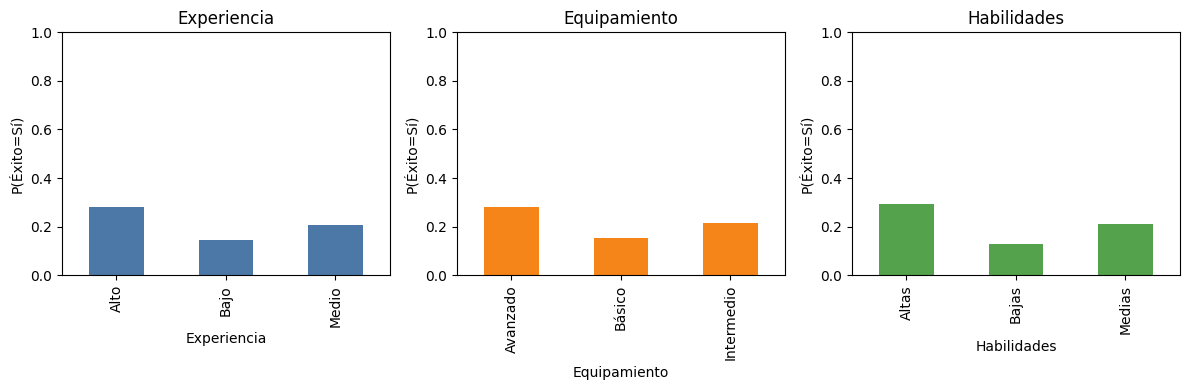

In [4]:
# Visualizar impacto de algunos atributos
resumen_exp = data.groupby('Experiencia')['ExitoMision'].apply(lambda s: (s == 'Sí').mean()).reset_index(name='P(Éxito=Sí)')
resumen_eq = data.groupby('Equipamiento')['ExitoMision'].apply(lambda s: (s == 'Sí').mean()).reset_index(name='P(Éxito=Sí)')
resumen_hab = data.groupby('Habilidades')['ExitoMision'].apply(lambda s: (s == 'Sí').mean()).reset_index(name='P(Éxito=Sí)')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
resumen_exp.plot(kind='bar', x='Experiencia', y='P(Éxito=Sí)', ax=axes[0], legend=False, color='#4C78A8')
resumen_eq.plot(kind='bar', x='Equipamiento', y='P(Éxito=Sí)', ax=axes[1], legend=False, color='#F58518')
resumen_hab.plot(kind='bar', x='Habilidades', y='P(Éxito=Sí)', ax=axes[2], legend=False, color='#54A24B')

axes[0].set_title('Experiencia')
axes[1].set_title('Equipamiento')
axes[2].set_title('Habilidades')

for ax in axes:
    ax.set_ylim(0, 1)
    ax.set_ylabel('P(Éxito=Sí)')

plt.tight_layout()

In [6]:
# Naive Bayes con variables categóricas
encoder = OrdinalEncoder()
X = encoder.fit_transform(data[['Experiencia', 'Equipamiento', 'Habilidades', 'Salud', 'EstadoMental']])
y = data['ExitoMision'].map({'No': 0, 'Sí': 1})

model = CategoricalNB()
model.fit(X, y)

# Ejemplos para estimar probabilidad de éxito
combinaciones = pd.DataFrame({
    'Experiencia': ['Alto', 'Bajo', 'Medio'],
    'Equipamiento': ['Avanzado', 'Básico', 'Intermedio'],
    'Habilidades': ['Altas', 'Bajas', 'Medias'],
    'Salud': ['Alta', 'Baja', 'Media'],
    'EstadoMental': ['Positivo', 'Negativo', 'Neutral']
})

X_new = encoder.transform(combinaciones)
probs = model.predict_proba(X_new)

combinaciones['P(Éxito=No)'] = probs[:, 0]
combinaciones['P(Éxito=Sí)'] = probs[:, 1]

combinaciones

,Experiencia,Equipamiento,Habilidades,Salud,EstadoMental,P(Éxito=No),P(Éxito=Sí)
0,Alto,Avanzado,Altas,Alta,Positivo,0.365607,0.634393
1,Bajo,Básico,Bajas,Baja,Negativo,0.981416,0.018584
2,Medio,Intermedio,Medias,Media,Neutral,0.788424,0.211576
